# Customer Churn Prediction Project

In this project, I am trying to predict whether a customer will leave (churn) or not based on different features like usage, payments, satisfaction, etc.

The main goal is to help businesses identify customers who are likely to leave so they can take action early.

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pylab as plt 
import seaborn as sns 
import re 
from sklearn.impute import SimpleImputer
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [ ]:
data = df = pd.read_csv("data/customer churn dataset.csv")

(250000, 15)

## Understanding the Dataset

First, I checked the shape and basic info of the dataset to understand what kind of data I am working with.

In [3]:
data.isnull().sum()

Customer Id                      0
Age                              0
Gender                           0
Region                           0
Contract Type                    0
Tenure Months                    0
Internet Service             11303
Monthly Charges                  0
Data Usage Gb                    0
Avg Call Duration Minutes        0
Support Calls                    0
Late Payments                    0
Payment Method                   0
Satisfaction Score               0
Churn                            0
dtype: int64

In [4]:
data.dtypes

Customer Id                    int64
Age                           object
Gender                        object
Region                        object
Contract Type                 object
Tenure Months                 object
Internet Service              object
Monthly Charges               object
Data Usage Gb                float64
Avg Call Duration Minutes    float64
Support Calls                  int64
Late Payments                  int64
Payment Method                object
Satisfaction Score             int64
Churn                          int64
dtype: object

In [5]:
data.head()

,Customer Id,Age,Gender,Region,Contract Type,Tenure Months,Internet Service,Monthly Charges,Data Usage Gb,Avg Call Duration Minutes,Support Calls,Late Payments,Payment Method,Satisfaction Score,Churn
0,1,56,Female,South Asia,Month-to-Month,42,5G,49.49,244.86,4.92,2,1,Digital Wallet,5,0
1,2,69,Male,EU,Two Year,23,DSL,92.74,211.98,4.04,4,0,DEBIT CARD,3,0
2,3,46,Female,LatAm,Month-to-Month,64 months,5G,26.95,179.35,6.92,3,0,Bank Transfer,7,0
3,4,32,female,North America,Month-to-Month,38,Fiber Optic,69.06,5.00,4.19,5,0,Credit Card,9,1
4,5,60,Male,Asia,One Year,57,Fiber Optic,64.55,193.71,4.09,2,1,DEBIT CARD,4,0


In [6]:
data.columns = data.columns.str.lower().str.replace(' ', '_').str.strip()

In [7]:
data['age'].unique()[:50]

array(['56', '69', '46', '32', '60', '25', '78', '38', '75', '36', '40',
       '28', '41', '70', '53', '57', '20', '39', '19', '61', '47', '55',
       '77', '50 yrs', '-29', '42', '66', '44', '76', '59', '45', '33',
       '32 yrs', '79', '64', '68', '72', '74', '54', '24', '26', '35',
       '21', '77 yrs', '31', '67', '43', '37', '-52', '34'], dtype=object)

In [8]:
data['gender'].unique()[:20]

array(['Female', 'Male', 'female', 'F', 'M', 'Female ', 'm', 'M ',
       'Male ', 'male', 'm ', 'F ', 'f', 'female ', 'male ', 'f '],
      dtype=object)

In [9]:
data['region'].unique()[:20]

array(['South Asia', 'EU', 'LatAm', 'North America', 'Asia',
       'South America', 'Europe', 'Africa', 'Sub-Saharan'], dtype=object)

In [10]:
data['contract_type'].unique()[:20]

array(['Month-to-Month', 'Two Year', 'One Year', 'MONTH-TO-MONTH',
       'ONE YEAR', 'TWO YEAR'], dtype=object)

In [11]:
data['tenure_months'].unique()[:20]

array(['42', '23', '64 months', '38', '57', '4', '26', '58', '19 months',
       '3', '52', '70', '56', '59', '33', '45', '54', '44', '12', '18'],
      dtype=object)

In [12]:
data['internet_service'].unique()[:20]

array(['5G', 'DSL', 'Fiber Optic', '5G ', 'Fibre Optics', 'Fiber Optic ',
       nan, 'DSL ', 'Fibre Optics ', 'nan '], dtype=object)

In [13]:
data['monthly_charges'].unique()[:20]

array(['49.49', '92.74', '26.95', '69.06', '64.55', '68.73', '68.81',
       '58.84', '39.6', '67.65', '48.16', '49.26$', '66.53', '57.48',
       '66.07', '78.16', '89.48', '84.88', '49.14', '52.98'], dtype=object)

In [14]:
data['data_usage_gb'].unique()[:20]

array([244.86, 211.98, 179.35,   5.  , 193.71, 129.62,  30.21, 210.58,
       120.33, 141.37,  37.62, 209.58, 101.92, 101.02, 133.45, 182.17,
       131.91, 147.49,   5.54,  94.88])

In [15]:
data['avg_call_duration_minutes'].unique()[:20]

array([ 4.92,  4.04,  6.92,  4.19,  4.09,  6.5 ,  4.49,  8.54,  8.53,
        3.93, 11.24,  2.3 ,  8.96,  4.15,  7.9 ,  3.9 ,  6.48,  4.62,
        5.43,  7.17])

In [16]:
data['support_calls'].unique()[:20]

array([ 2,  4,  3,  5,  1, 17, 18,  0,  6, 20,  7, 22, 16,  8, 19, 21, 23,
        9, 10, 24])

In [17]:
data['late_payments'].unique()[:20]

array([ 1,  0,  4,  2,  5,  3, 15, 10, 20,  6, 25,  7,  8, 30])

In [18]:
data['payment_method'].unique()[:20]

array(['Digital Wallet', 'DEBIT CARD', 'Bank Transfer', 'Credit Card',
       'Debit Card', 'CREDIT CARD', 'BANK TRANSFER', 'DIGITAL WALLET'],
      dtype=object)

In [19]:
data['satisfaction_score'].unique()[:20]

array([  5,   3,   7,   9,   4,   8,  10,  -9,  -5,   1,   2,   6,  -7,
        -6,  -8,  -2,  -3,  -1, -10,  -4])

In [20]:
data['churn'].unique()

array([0, 1])

In [21]:
df = data.copy()
df.drop(columns=['customer_id'], inplace=True)

In [22]:
df.head()

,age,gender,region,contract_type,tenure_months,internet_service,monthly_charges,data_usage_gb,avg_call_duration_minutes,support_calls,late_payments,payment_method,satisfaction_score,churn
0,56,Female,South Asia,Month-to-Month,42,5G,49.49,244.86,4.92,2,1,Digital Wallet,5,0
1,69,Male,EU,Two Year,23,DSL,92.74,211.98,4.04,4,0,DEBIT CARD,3,0
2,46,Female,LatAm,Month-to-Month,64 months,5G,26.95,179.35,6.92,3,0,Bank Transfer,7,0
3,32,female,North America,Month-to-Month,38,Fiber Optic,69.06,5.00,4.19,5,0,Credit Card,9,1
4,60,Male,Asia,One Year,57,Fiber Optic,64.55,193.71,4.09,2,1,DEBIT CARD,4,0


In [23]:
df['age']=df['age'].astype(str).str.lower().str.extract(r'(\d+)')#(\d+) will get only numeric values
df['age']=pd.to_numeric(df['age'],errors='coerce')

df.loc[df['age'] < 0, 'age'] = None
df.loc[df['age'] > 100, 'age'] = None
df['age'].fillna(df['age'].median(), inplace=True)

In [24]:
df['gender']=df['gender'].astype(str).str.strip().str.lower()
df['gender']=df['gender'].replace(
    {
        'm':'male',
        'f':'female'
    }
)

In [25]:
df['region'].unique()[:20]
df['region'] = df['region'].astype(str).str.strip().str.lower()
region_map = {
    'south asia':'asia', 
    'eu':'europe', 
    'latam':'latam', 
    'north america':'north_america', 
    'asia':'asia',    
    'south america':'south_america', 
    'europe':'europe', 
    'africa':'africa', 
    'sub-saharan':'africa',
    'australia': 'australia'
}
df['region'] = df['region'].replace(region_map)

In [26]:
df['contract_type'].unique()[:20]
df['contract_type'] = df['contract_type'].astype(str).str.lower().str.strip()
df['contract_type'] = df['contract_type'].str.replace(r'[^a-z0-9 ]', '', regex=True)
df['contract_type'] = df['contract_type'].str.replace(r'\s+', ' ', regex=True)
def clean_contract(x):
    x = str(x)
    if 'month' in x:
        return 'month_to_month'
    elif '1' in x or 'one' in x:
        return 'one_year'
    elif '2' in x or 'two' in x:
        return 'two_year'
    else:
        return 'unknown'
df['contract_type'] = df['contract_type'].apply(clean_contract)

In [27]:
df['contract_type'].unique()

array(['month_to_month', 'two_year', 'one_year'], dtype=object)

In [28]:
df['tenure_months'] = df['tenure_months'].astype(str).str.extract(r'(\d+)')
df['tenure_months'] = pd.to_numeric(df['tenure_months'], errors='coerce')

df.loc[df['tenure_months'] < 0, 'tenure_months'] = np.nan

df['tenure_months'] = df['tenure_months'].fillna(df['tenure_months'].median())

In [29]:
df.loc[df['tenure_months'] > 120, 'tenure_months'] = np.nan
df['tenure_months'] = df['tenure_months'].round().astype(int)

In [30]:
df['tenure_months'].unique()[:100]

array([42, 23, 64, 38, 57,  4, 26, 58, 19,  3, 52, 70, 56, 59, 33, 45, 54,
       44, 12, 18, 40, 27, 22, 69, 16, 17, 55, 53, 61, 51, 66, 14, 30, 36,
        7,  1, 41, 29, 60, 46, 15, 49, 25, 68, 24, 65, 11, 31, 37, 43, 71,
       48, 32,  5,  9, 67, 47, 34, 20, 62, 35, 50,  8, 63, 28, 39,  6,  2,
       13, 21, 10])

In [31]:
clean_categories = ['internet_service','payment_method']
for col in clean_categories:
    df[col]= df[col].astype(str).str.lower().str.strip()
    df[col]= df[col].replace(r'[^a-z0-9 ]','',regex = True)
    df[col]= df[col].replace(r'\s+','_',regex = True)

In [32]:
df['internet_service']=df['internet_service'].replace({
    '5g':'5g',
    'dsl':'dsl',
    'fiber_optic':'optics',
    'fibre_optics':'optics',
    'nan': 'unknown'
})
df['internet_service'] = df['internet_service'].fillna('unknown')

In [33]:
df['internet_service'].unique()

array(['5g', 'dsl', 'optics', 'unknown'], dtype=object)

In [34]:
def clean_payment(x):
    if 'card' in x:
        return 'card'
    elif'bank' in x:
        return 'bank'
    elif 'wallet' in x or 'upi' in x:
        return 'wallet'
    else :
        return 'other'
df['payment_method']=df['payment_method'].apply(clean_payment)

In [35]:
df['payment_method'].unique()

array(['wallet', 'card', 'bank'], dtype=object)

In [36]:
num_cols = [
    'monthly_charges',
    'data_usage_gb',
    'avg_call_duration_minutes',
    'support_calls',
    'late_payments',
    'satisfaction_score'
]

In [37]:
for col in num_cols:
    df[col] = df[col].astype(str).str.lower().str.strip()
    df[col] = df[col].replace(r'[^0-9.]','',regex = True)
    df[col] = pd.to_numeric(df[col],errors = 'coerce')

In [38]:
df.loc[df['monthly_charges']<0 ,'monthly_charges'] = np.nan

In [39]:
df.loc[df['data_usage_gb']<0,'data_usage_gb'] = np.nan

In [40]:
df.loc[df['avg_call_duration_minutes'] < 0, 'avg_call_duration_minutes'] = np.nan

In [41]:
df.loc[df['support_calls'] > 50, 'support_calls'] = np.nan
df['support_calls'].unique()

array([ 2.,  4.,  3.,  5.,  1., 17., 18.,  0.,  6., 20.,  7., 22., 16.,
        8., 19., 21., 23.,  9., 10., 24., 26., 25.])

In [42]:
df.loc[df['late_payments'] > 24, 'late_payments'] = np.nan
df['late_payments'].unique()

array([ 1.,  0.,  4.,  2.,  5.,  3., 15., 10., 20.,  6., nan,  7.,  8.])

In [43]:
df.loc[(df['satisfaction_score'] < 0) | (df['satisfaction_score'] > 10), 'satisfaction_score'] = np.nan
df['satisfaction_score'].unique()

array([ 5.,  3.,  7.,  9.,  4.,  8., 10.,  1.,  2.,  6.])

In [44]:
int_cols = ['age', 'tenure_months', 'support_calls', 'late_payments', 'satisfaction_score']
df[int_cols] = df[int_cols].round()

In [45]:
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [46]:
df.describe()

,age,tenure_months,monthly_charges,data_usage_gb,avg_call_duration_minutes,support_calls,late_payments,satisfaction_score,churn
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,48.477260,35.994648,70.139377,120.777795,6.000264,2.799008,1.196036,5.502472,0.305952
std,17.890369,20.484175,24.488268,58.535946,1.984779,3.756187,1.691662,2.869427,0.460810
min,18.000000,1.000000,20.000000,5.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,33.000000,18.000000,53.100000,79.690000,4.650000,1.000000,0.000000,3.000000,0.000000
50%,48.000000,36.000000,69.910000,120.140000,5.990000,2.000000,1.000000,6.000000,0.000000
75%,64.000000,54.000000,86.840000,160.600000,7.350000,3.000000,2.000000,8.000000,1.000000
max,79.000000,71.000000,150.000000,385.560000,14.680000,26.000000,20.000000,10.000000,1.000000


## EDA AND VISUALIZATION

In [47]:
df['churn'].value_counts()
df['churn'].value_counts(normalize=True)

churn
0    0.694048
1    0.305952
Name: proportion, dtype: float64

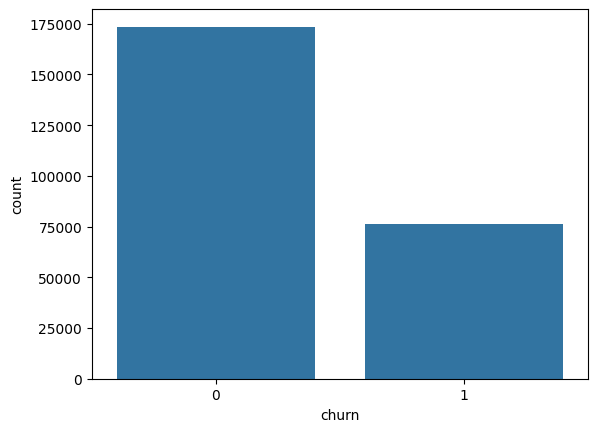

In [48]:
sns.countplot(x='churn', data = df);

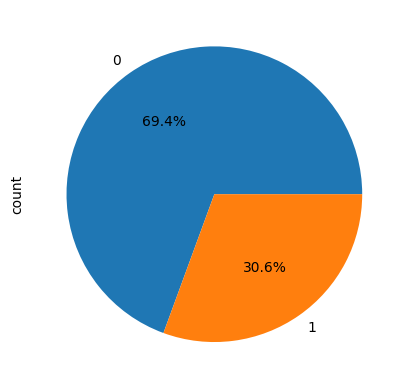

In [49]:
df['churn'].value_counts().plot.pie(autopct='%1.1f%%');

## Univariate Analysis

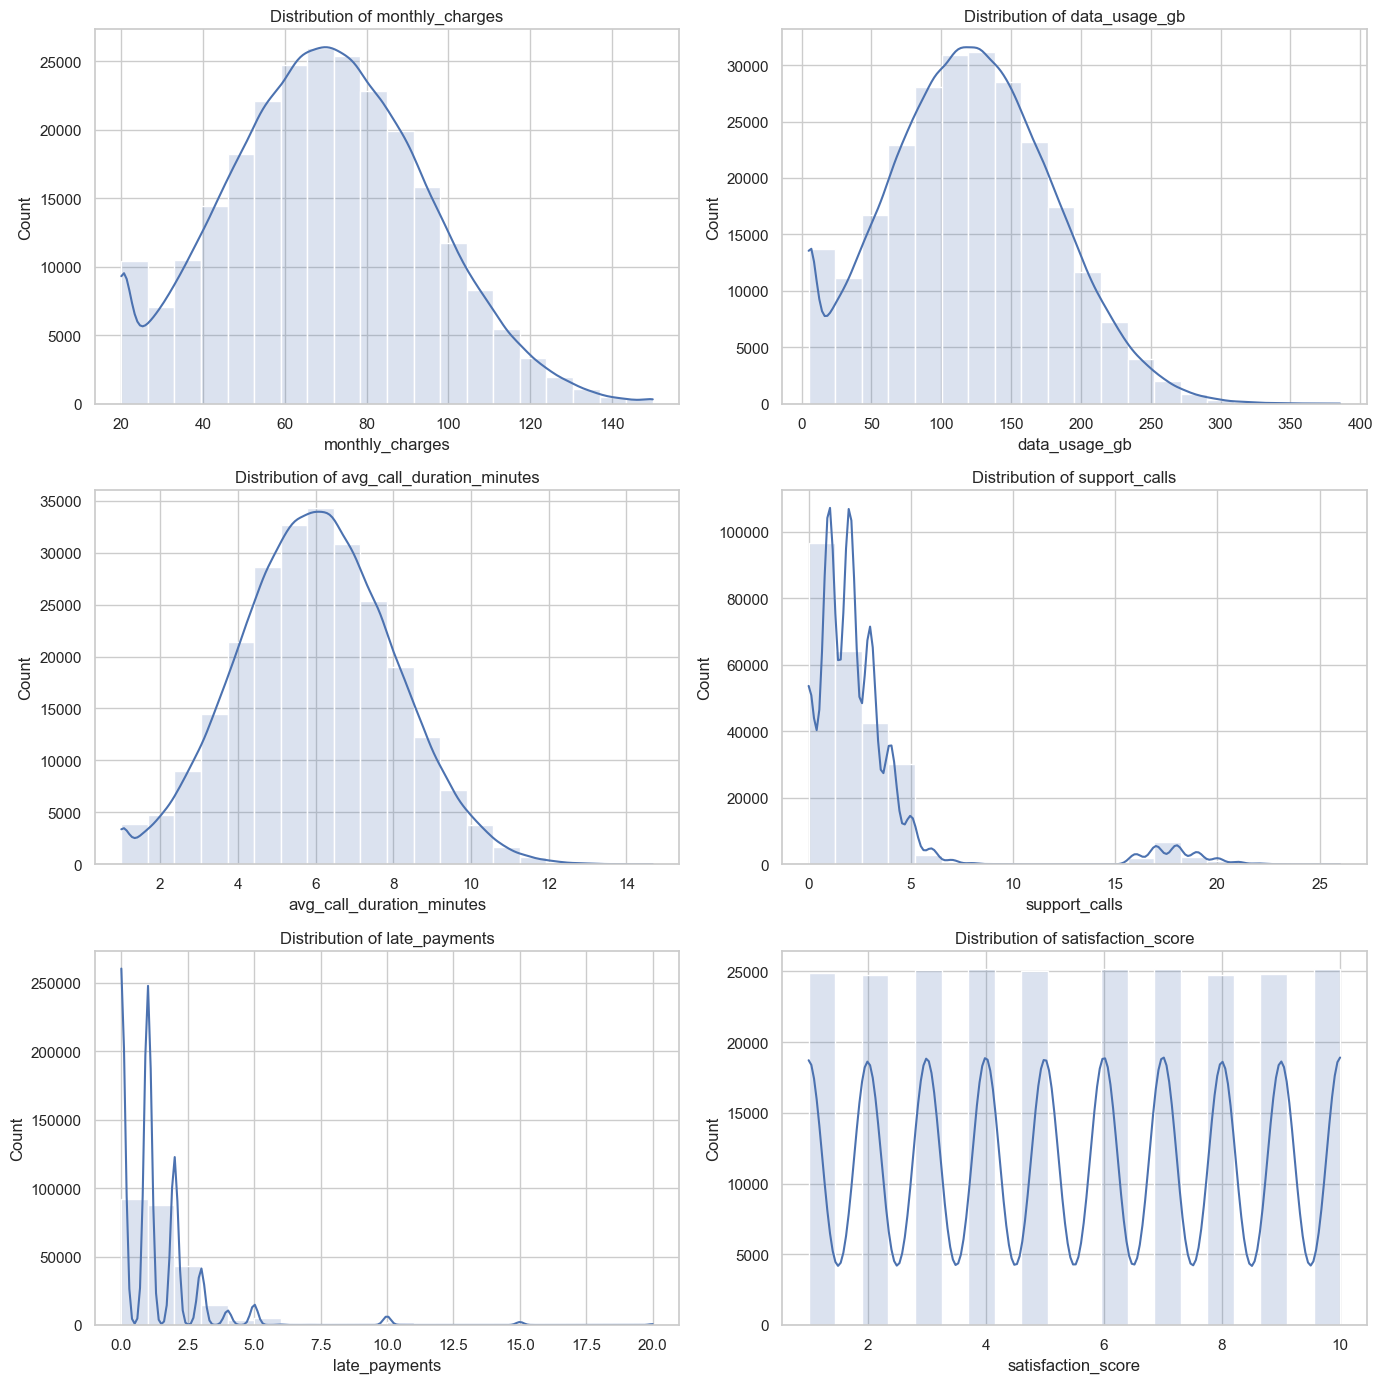

In [50]:
sns.set(style='whitegrid')

fig, axes = plt.subplots(3, 2, figsize=(14,14))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        df[col],
        bins=20,
        kde=True,
        ax=axes[i],
        alpha=0.2
    )
    
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)

plt.tight_layout()
plt.show()

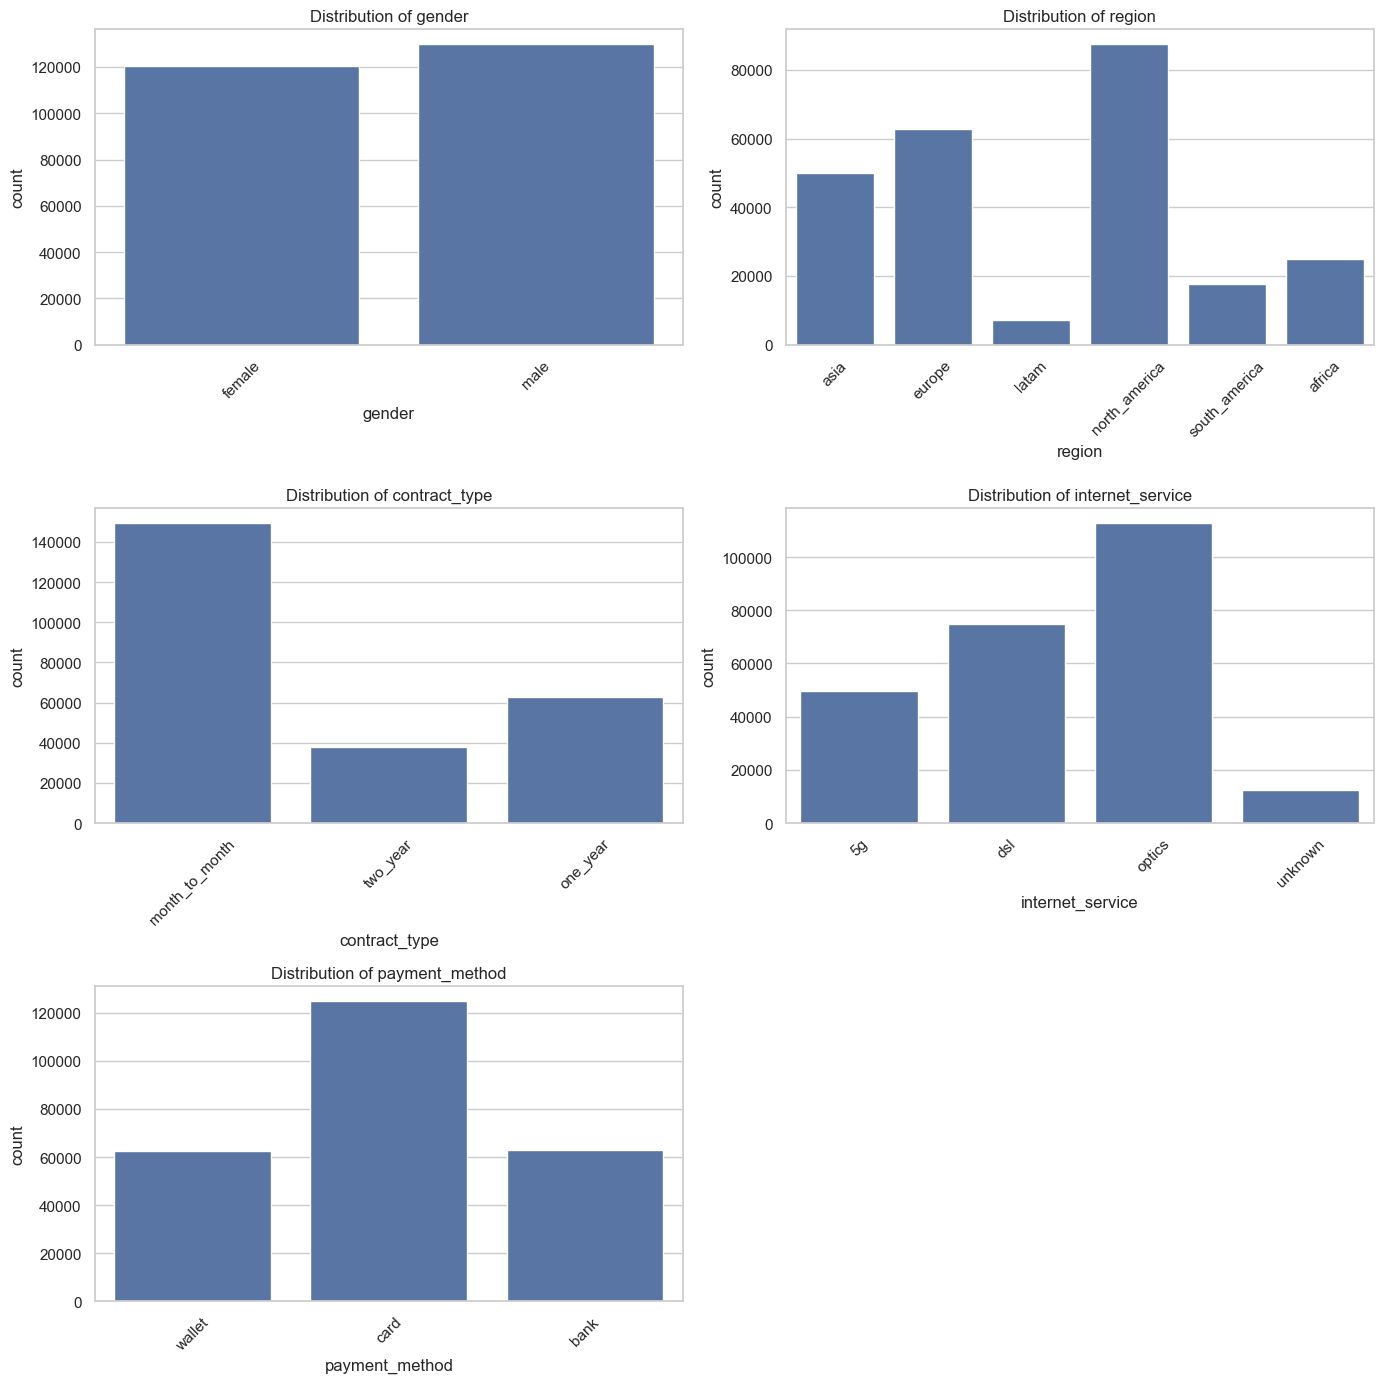

In [51]:
cat_features = ['gender','region','contract_type','internet_service','payment_method']

fig, axes = plt.subplots(3, 2, figsize=(14,14))
axes = axes.flatten()
for i, col in enumerate(cat_features):
    sns.countplot(x=col, data=df, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=45)
fig.delaxes(axes[-1])# Remove extra empty plot (since 5 features, 6 slots)
plt.tight_layout()
plt.show()

## Bivariate Analysis

### Numerical vs Churn

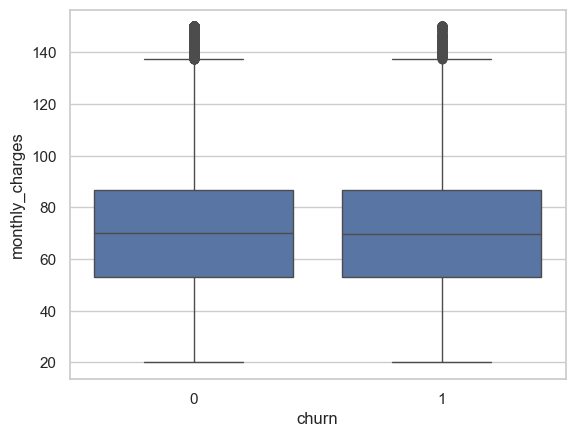

In [52]:
sns.boxplot(x='churn', y='monthly_charges', data=df);

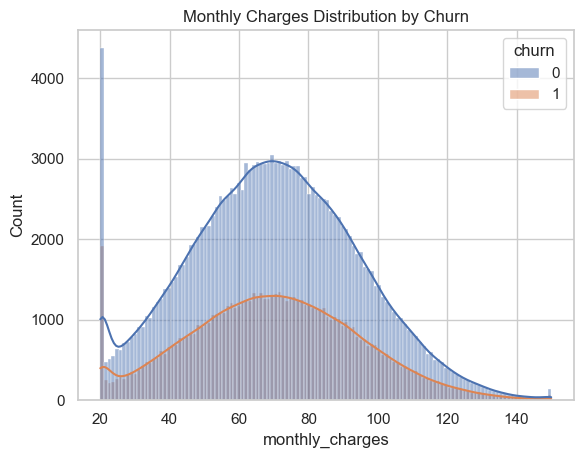

In [53]:
sns.histplot(data=df, x='monthly_charges', hue='churn', kde=True)
plt.title('Monthly Charges Distribution by Churn')
plt.show()

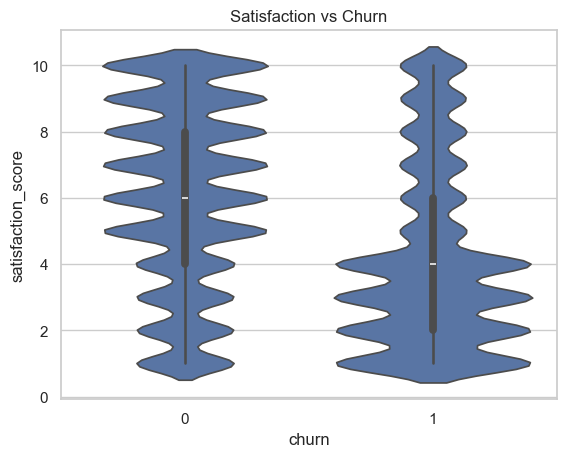

In [54]:
sns.violinplot(x='churn', y='satisfaction_score', data=df)
plt.title('Satisfaction vs Churn')
plt.show()

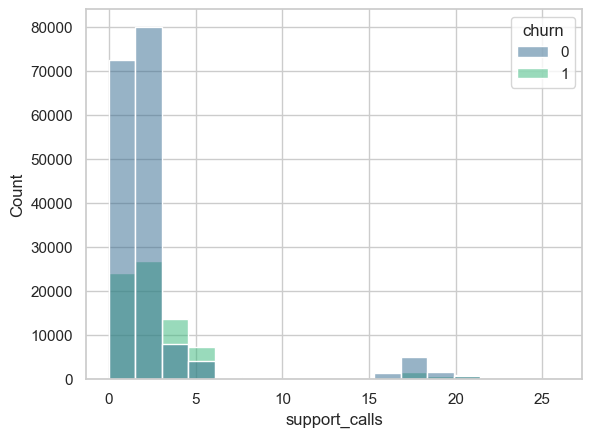

In [55]:
sns.histplot(data=df, x='support_calls', hue='churn', bins=17,palette='viridis',
             alpha=0.5);

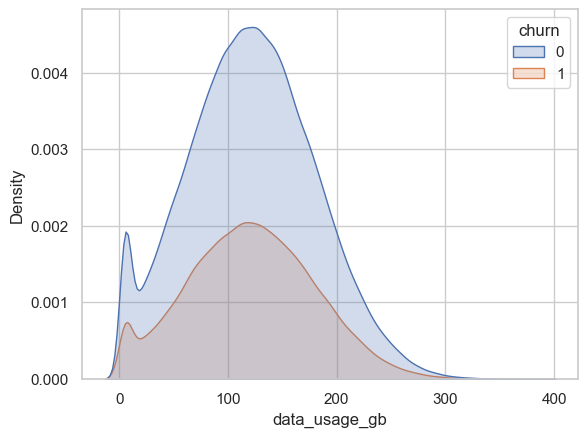

In [56]:
sns.kdeplot(data=df, x='data_usage_gb', hue='churn', fill=True);

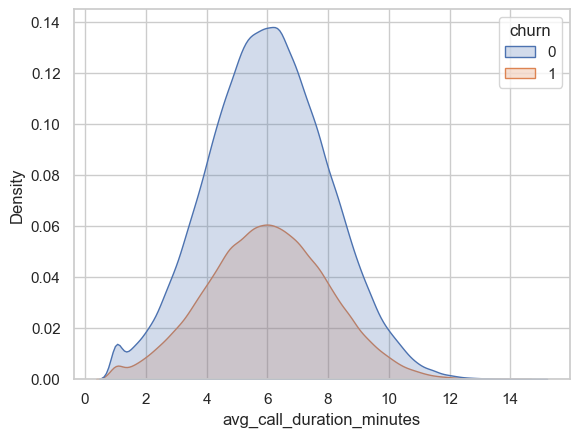

In [57]:
sns.kdeplot(data=df, x='avg_call_duration_minutes', hue='churn', fill=True);
## weak feature almost overlap graph 

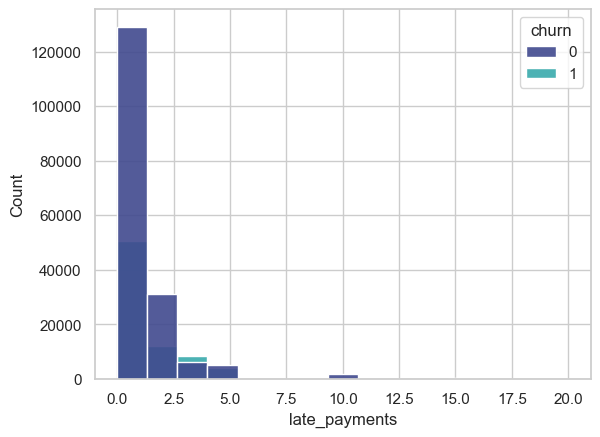

In [58]:
sns.histplot(data=df, x='late_payments', hue='churn', bins=15,
            palette='mako',
             alpha=0.9);

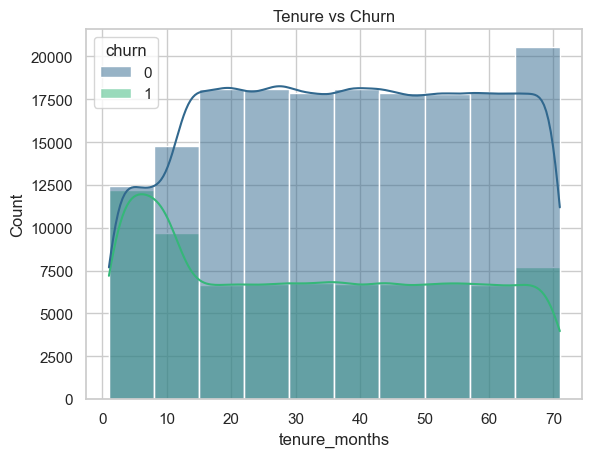

In [59]:
sns.histplot(data=df, x='tenure_months', hue='churn', 
             fill=True,
             bins = 10,
             palette='viridis',
             alpha=0.5,kde = True)
plt.title('Tenure vs Churn')
plt.show();

### Categorical vs Churn

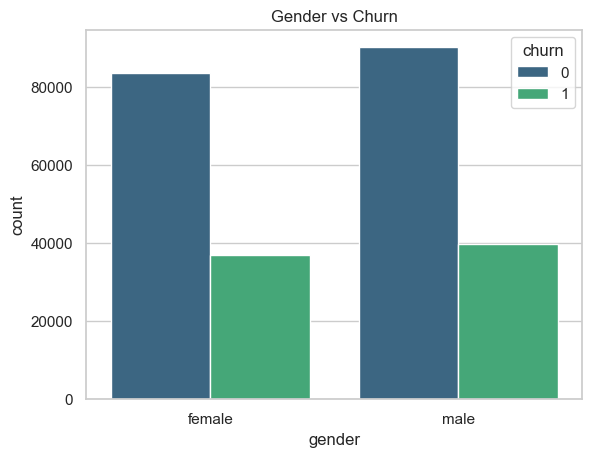

In [60]:
sns.countplot(x='gender', hue='churn', data=df, palette='viridis')
plt.title('Gender vs Churn')
plt.show()

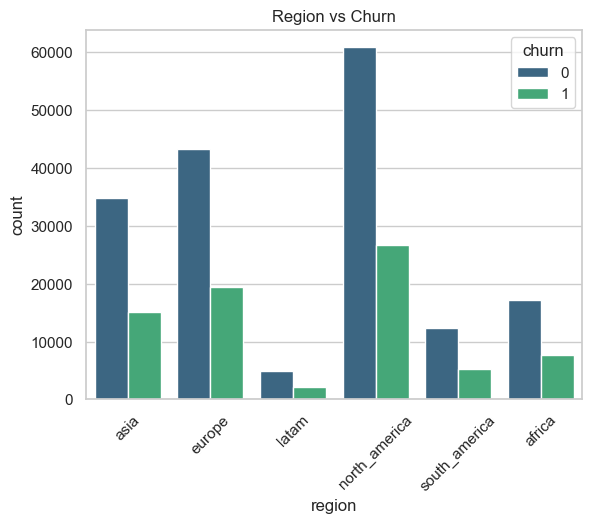

In [61]:
sns.countplot(x='region', hue='churn', data=df, palette='viridis')
plt.title('Region vs Churn')
plt.xticks(rotation=45)
plt.show()

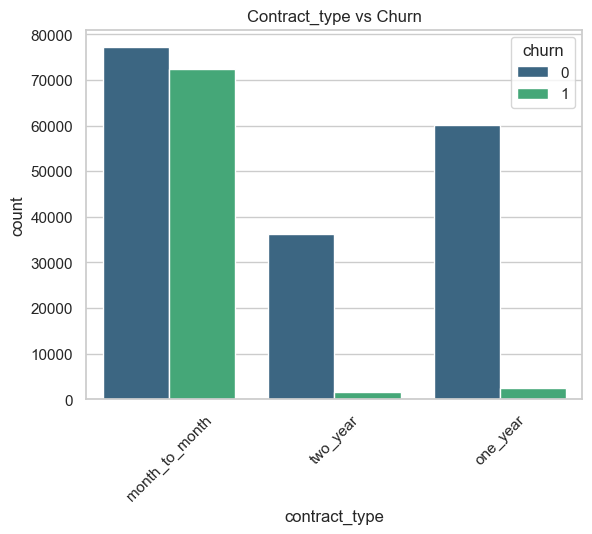

In [62]:
sns.countplot(x='contract_type', hue='churn', data=df,palette='viridis')
plt.title('Contract_type vs Churn')
plt.xticks(rotation=45)
plt.show()

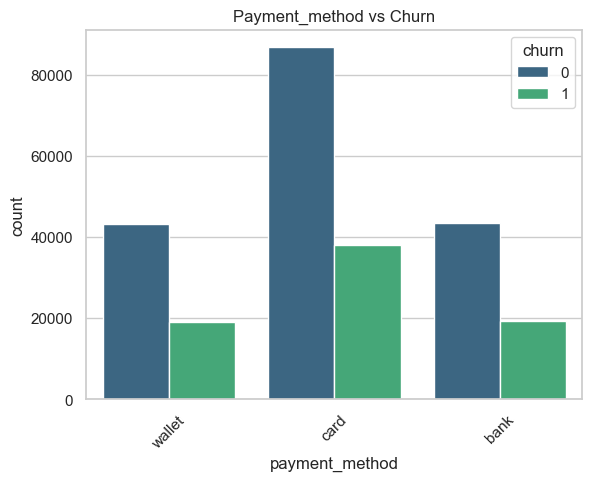

In [63]:
sns.countplot(x='payment_method', hue='churn', data=df,palette='viridis')
plt.title('Payment_method vs Churn')
plt.xticks(rotation=45)
plt.show()

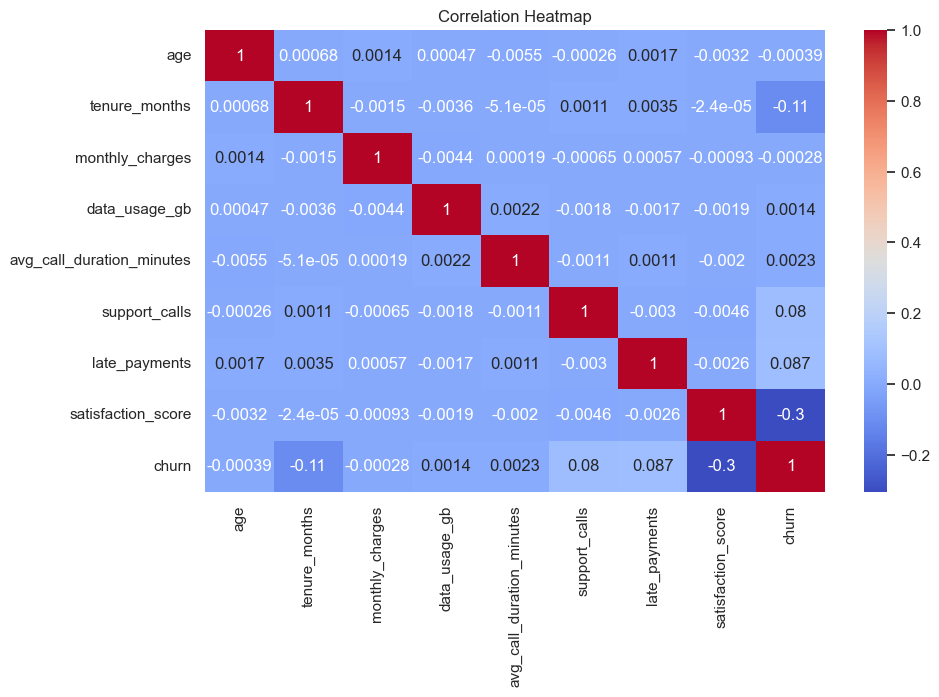

In [64]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Exploratory Data Analysis (EDA)

I explored the dataset to understand patterns and relationships between features.

Some observations:
- Certain features like satisfaction score and support calls seem related to churn
- Data is slightly imbalanced (more non-churn than churn)

# 📊 Feature Selection Summary (Churn Prediction)

## 🟢 Important Features (Use in Model)
- late_payments → very strong positive correlation (high delay = high churn)
- support_calls → strong positive correlation (more issues = more churn)
- satisfaction_score → moderate negative correlation (low score = high churn)
- contract_type → very strong categorical pattern (month-to-month = high churn)

---

## 🟡 Moderate Features (Optional)
- payment_method → slight variation in churn
- region → minor differences
- tenure_months → weak negative correlation (low impact but usable)

---

## 🔴 Weak Features (Drop)
- monthly_charges → very weak / overlapping
- avg_call_duration_minutes → weak correlation
- data_usage_gb → no meaningful pattern
- gender → no impact

---

# ⚡ Final Rule
- Use → strong + moderate features  
- Drop → weak / near-zero correlation features  

## Outliers handling 

In [65]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(col, "Outliers:", len(outliers))

monthly_charges Outliers: 819
data_usage_gb Outliers: 856
avg_call_duration_minutes Outliers: 826
support_calls Outliers: 13561
late_payments Outliers: 3374
satisfaction_score Outliers: 0


In [66]:
for col in num_cols:
    Q1= df[col].quantile(0.25)
    Q3= df[col].quantile(0.75)
    IQR = Q3-Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    df[col]= df[col].clip(lower,upper)

In [67]:
## Train Test split 
X = df[[
        'late_payments',
        'support_calls',
        'satisfaction_score',
        'tenure_months',
        'contract_type',
        'payment_method',
        'region'
    ]]
y = df['churn']
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,
                                                 test_size=0.20,
                                                 stratify=y,
                                                 random_state=42
                                                )

In [68]:
cat_cols = ['region','contract_type', 'payment_method']

num_cols = [
    'tenure_months','support_calls', 
    'late_payments','satisfaction_score'
]

## Data Preprocessing

Before training the model, I performed:
- Train-test split
- Encoding for categorical variables
- Scaling (only where needed)

I used pipelines to keep everything clean and avoid data leakage.

## Encoding 

In [69]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
        ("num", StandardScaler(), num_cols)
    ],
    remainder='passthrough'
)

In [70]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
        ("num", StandardScaler(), num_cols)
    ],
    remainder='passthrough'
)

In [71]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
preprocessor_no_scale = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
    ],
    remainder='passthrough'
)

## Model Training

I trained multiple models to compare performance:
- Logistic Regression
- Random Forest
- Gradient Boosting
- XGBoost
- AdaBoost

Each model was evaluated using accuracy, F1-score, and recall.

In [72]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
models = {
    "log_reg": (preprocessor_scaled,LogisticRegression(max_iter=1000, class_weight="balanced")),
 
    "rf": (preprocessor_no_scale,RandomForestClassifier(n_estimators=200, random_state=42)),
    "xgb":(preprocessor_no_scale,XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5
    )),
    "gb": (preprocessor_no_scale,GradientBoostingClassifier()),
    "ada": (preprocessor_no_scale,AdaBoostClassifier())
}

In [73]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, f1_score,recall_score
from tqdm import tqdm
results = {}
for name, (prep, model) in tqdm(models.items()):
    
    pipe = Pipeline([
        ("preprocessing", prep),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)

    # Predictions
    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)
    
    # Accuracy
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    # F1 score (important for imbalance)
    f1 = f1_score(y_test, y_test_pred)
    
    results[name] = test_acc
    
    print(f"\n{name}")
    print("Train Accuracy:", train_acc)
    print("Test Accuracy :", test_acc)
    print("F1 Score      :", f1)
    print("Time taken    :", round(2), "sec")
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_test_pred))

 20%|██        | 1/5 [00:00<00:02,  1.98it/s]


log_reg
Train Accuracy: 0.79865
Test Accuracy : 0.79812
F1 Score      : 0.7198601243339254
Time taken    : 2 sec

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.78      0.84     34702
           1       0.63      0.85      0.72     15298

    accuracy                           0.80     50000
   macro avg       0.77      0.81      0.78     50000
weighted avg       0.83      0.80      0.80     50000



 40%|████      | 2/5 [00:26<00:47, 15.76s/it]


rf
Train Accuracy: 0.961425
Test Accuracy : 0.85122
F1 Score      : 0.7564098366023773
Time taken    : 2 sec

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89     34702
           1       0.76      0.76      0.76     15298

    accuracy                           0.85     50000
   macro avg       0.82      0.82      0.82     50000
weighted avg       0.85      0.85      0.85     50000



 60%|██████    | 3/5 [00:27<00:17,  8.93s/it]


xgb
Train Accuracy: 0.884835
Test Accuracy : 0.88026
F1 Score      : 0.8139354197097306
Time taken    : 2 sec

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.89      0.91     34702
           1       0.78      0.86      0.81     15298

    accuracy                           0.88     50000
   macro avg       0.85      0.87      0.86     50000
weighted avg       0.89      0.88      0.88     50000



 80%|████████  | 4/5 [00:40<00:10, 10.59s/it]


gb
Train Accuracy: 0.88193
Test Accuracy : 0.88022
F1 Score      : 0.807136186519821
Time taken    : 2 sec

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.91      0.91     34702
           1       0.80      0.82      0.81     15298

    accuracy                           0.88     50000
   macro avg       0.86      0.86      0.86     50000
weighted avg       0.88      0.88      0.88     50000



100%|██████████| 5/5 [00:45<00:00,  9.08s/it]


ada
Train Accuracy: 0.87498
Test Accuracy : 0.87314
F1 Score      : 0.7902100214982636
Time taken    : 2 sec

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.91     34702
           1       0.80      0.78      0.79     15298

    accuracy                           0.87     50000
   macro avg       0.85      0.85      0.85     50000
weighted avg       0.87      0.87      0.87     50000



## Hyperparameter Tuning

After comparing models, I selected the top-performing ones and applied RandomizedSearchCV with cross-validation to improve performance.

## HyperParameter tuning

## XG BOOSTING

In [74]:
from sklearn.model_selection import RandomizedSearchCV
xgb_pipe = Pipeline([
    ("Preprocessing",preprocessor_no_scale),
    ("Model",XGBClassifier())
])
xgb_params = {
    'Model__n_estimators': [100,200, 300, 500,600],
    'Model__learning_rate': [0.01,0.05, 0.1],
    'Model__max_depth': [4, 5, 6],
    'Model__min_child_weight': [1, 3, 5],
    'Model__subsample': [0.8, 1],
    'Model__colsample_bytree': [0.8, 1],
    'Model__reg_lambda': [1, 5],
    'Model__reg_alpha': [0, 0.1]
}
xgb_model = RandomizedSearchCV(
    xgb_pipe,
    xgb_params,
    n_iter=25,
    cv = 3 , 
    scoring="roc_auc", 
    verbose=0
)
xgb_model.fit(X_train,y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'Model__colsample_bytree': [0.8, 1], 'Model__learning_rate': [0.01, 0.05, ...], 'Model__max_depth': [4, 5, ...], 'Model__min_child_weight': [1, 3, ...], ...}"
,n_iter,25
,scoring,'roc_auc'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


## AdaBoost

In [75]:
from sklearn.tree import DecisionTreeClassifier
ada_pipe = Pipeline([
    ("Preprocessing", preprocessor_no_scale),
    ("Model",AdaBoostClassifier())
])
ada_params = {
    'Model__n_estimators': [50, 100, 200, 300],
    'Model__learning_rate': [0.01, 0.05, 0.1, 1],
    'Model__estimator': [
        DecisionTreeClassifier(max_depth=1),
        DecisionTreeClassifier(max_depth=2),
        DecisionTreeClassifier(max_depth=3)
    ],
    'Model__algorithm': ['SAMME']
}
ada_model = RandomizedSearchCV(
    ada_pipe,
    ada_params,
    n_iter=25,
    cv=3,
    scoring="roc_auc", 
    verbose=0,
    n_jobs =-1
)
ada_model.fit(X_train,y_train)

,estimator,Pipeline(step...lassifier())])
,param_distributions,"{'Model__algorithm': ['SAMME'], 'Model__estimator': [DecisionTreeC...r(max_depth=1), DecisionTreeC...r(max_depth=2), ...], 'Model__learning_rate': [0.01, 0.05, ...], 'Model__n_estimators': [50, 100, ...]}"
,n_iter,25
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


## Gradient Boosting

In [76]:
gb_pipe = Pipeline([
    ("Preprocessing",preprocessor_no_scale),
    ("Model",GradientBoostingClassifier())
])
gb_params = {
    'Model__n_estimators': [100, 200, 300],
    'Model__learning_rate': [0.05, 0.1],
    'Model__max_depth': [3, 4, 5],
    'Model__min_samples_split': [2, 5, 10],
    'Model__min_samples_leaf': [1, 2, 4],
    'Model__subsample': [0.8, 1.0],
    'Model__max_features': ['sqrt', 'log2', None],
    'Model__loss': ['log_loss']
}
gb_model = RandomizedSearchCV(
    gb_pipe,
    gb_params,
    n_iter=10,
    cv=2,
    scoring="roc_auc", 
    verbose=1,
    n_jobs =-1
)
gb_model.fit(X_train,y_train)

Fitting 2 folds for each of 10 candidates, totalling 20 fits


,estimator,Pipeline(step...lassifier())])
,param_distributions,"{'Model__learning_rate': [0.05, 0.1], 'Model__loss': ['log_loss'], 'Model__max_depth': [3, 4, ...], 'Model__max_features': ['sqrt', 'log2', ...], ...}"
,n_iter,10
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,2
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


## Final Model Evaluation

After tuning, I evaluated the best models on the test dataset to check real-world performance.

I focused more on recall and F1-score since this is an imbalanced classification problem.

In [77]:
print("XGB Best:", xgb_model.best_score_)
print("GB  Best:", gb_model.best_score_)
print("ADA Best:", ada_model.best_score_)

XGB Best: 0.9429646279396052
GB  Best: 0.9429175032343359
ADA Best: 0.942410059663071


In [78]:
from sklearn.metrics import f1_score, recall_score
models_best = {
    "XGB": xgb_model.best_estimator_,
    "GB": gb_model.best_estimator_,
    "ADA": ada_model.best_estimator_
}

for name, model in models_best.items():
    
    print(f"\n{name}")
    
    # Predictions
    y_hypertrain_pred = model.predict(X_train)
    y_hypertest_pred = model.predict(X_test)

    # Metrics
    train_accuracy = accuracy_score(y_train, y_hypertrain_pred)
    test_accuracy = accuracy_score(y_test, y_hypertest_pred)
    f1 = f1_score(y_test, y_hypertest_pred)
    recall = recall_score(y_test, y_hypertest_pred)

    print("Train Accuracy:", train_accuracy)
    print("Test Accuracy :", test_accuracy)
    print("F1 Score      :", f1)
    print("Recall (churn):", recall)

    print("\nClassification Report:")
    print(classification_report(y_test, y_hypertest_pred))


XGB
Train Accuracy: 0.883295
Test Accuracy : 0.8805
F1 Score      : 0.8132287205776625
Recall (churn): 0.8503072297032291

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.89      0.91     34702
           1       0.78      0.85      0.81     15298

    accuracy                           0.88     50000
   macro avg       0.86      0.87      0.86     50000
weighted avg       0.88      0.88      0.88     50000


GB
Train Accuracy: 0.883655
Test Accuracy : 0.88068
F1 Score      : 0.8154883404465887
Recall (churn): 0.8618120015688325

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.89      0.91     34702
           1       0.77      0.86      0.82     15298

    accuracy                           0.88     50000
   macro avg       0.85      0.88      0.86     50000
weighted avg       0.89      0.88      0.88     50000


ADA
Train Accuracy: 0.88225
Test Accuracy : 0.8807


## Confusion Matrix

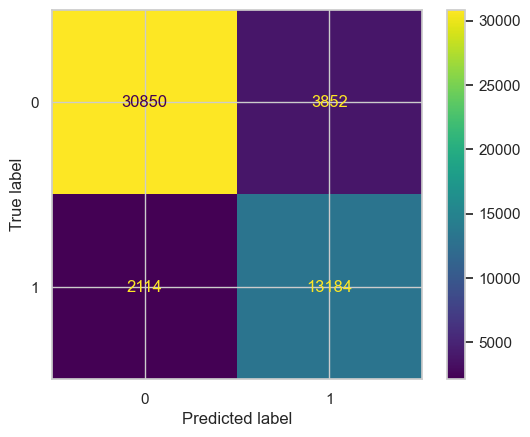

In [79]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred = (gb_model.best_estimator_).predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot();

### Confusion Matrix Explanation

- True Positive (TP): Model correctly predicts churn
- True Negative (TN): Model correctly predicts non-churn
- False Positive (FP): Model predicts churn but customer stays
- False Negative (FN): Model misses a churn customer

In this problem, False Negatives are more important because missing a churn customer means losing business.

## ROC Curve

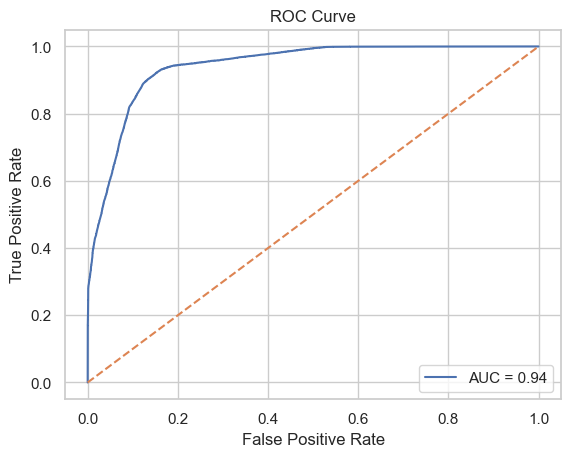

In [80]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = (gb_model.best_estimator_).predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### ROC Curve

The ROC curve shows how well the model separates churn and non-churn customers.

AUC score closer to 1 means better performance.
In my case, the model achieved a high AUC score, which indicates strong classification ability.

## Final Model Selection

After comparing all models, Gradient Boosting performed the best.

Reasons:
- Highest recall for churn customers
- Good F1-score
- No overfitting (train and test scores are close)

This model provides a good balance between performance and generalization.

## Conclusion

The final model can successfully identify customers who are likely to churn.

Key points:
- Achieved around 88% accuracy
- Recall for churn is around 86%
- Model generalizes well (no major overfitting)

This can help businesses take action early and reduce customer loss.

In [ ]:
import joblib
import pandas as pd

# Load trained model
model = joblib.load("models/churn_model.pkl")

print("\n--- Customer Churn Prediction ---")

# Take input from user
tenure = int(input("Enter tenure (months): "))
support_calls = int(input("Enter number of support calls: "))
late_payments = int(input("Enter number of late payments: "))
satisfaction_score = int(input("Enter satisfaction score (1-5): "))

contract_type = input("Enter contract type (monthly/yearly): ")
payment_method = input("Enter payment method (card/bank/upi): ")
region = input("Enter region: ")

# Create dataframe (VERY IMPORTANT → same column names)
data = pd.DataFrame({
    "tenure_months": [tenure],
    "support_calls": [support_calls],
    "late_payments": [late_payments],
    "satisfaction_score": [satisfaction_score],
    "contract_type": [contract_type],
    "payment_method": [payment_method],
    "region": [region]
})

# Predict
prediction = model.predict(data)[0]
prob = model.predict_proba(data)[0][1]

print("\n--- Result ---")

if prediction == 1:
    print("⚠️ Customer is likely to CHURN")
else:
    print("✅ Customer is likely to STAY")

print(f"Churn Probability: {round(prob*100, 2)}%")


--- Customer Churn Prediction ---

--- Result ---
⚠️ Customer is likely to CHURN
Churn Probability: 80.08%
